In [1]:
# IMPORTS 
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print(" All libraries imported!")

 All libraries imported!


In [2]:
# LOAD DATA 
df = pd.read_csv("CarPrice_Assignment.csv")

print("="*50)
print("CAR PRICE PREDICTION")
print("="*50)

print(f"\n First 5 rows:")
print(df.head())

print(f"\n Shape: {df.shape}")
print(f"\n Columns: {list(df.columns)}")
print(f"\n Missing values:")
print(df.isnull().sum())
print(f"\n Statistics:")
print(df.describe())

CAR PRICE PREDICTION

 First 5 rows:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressio

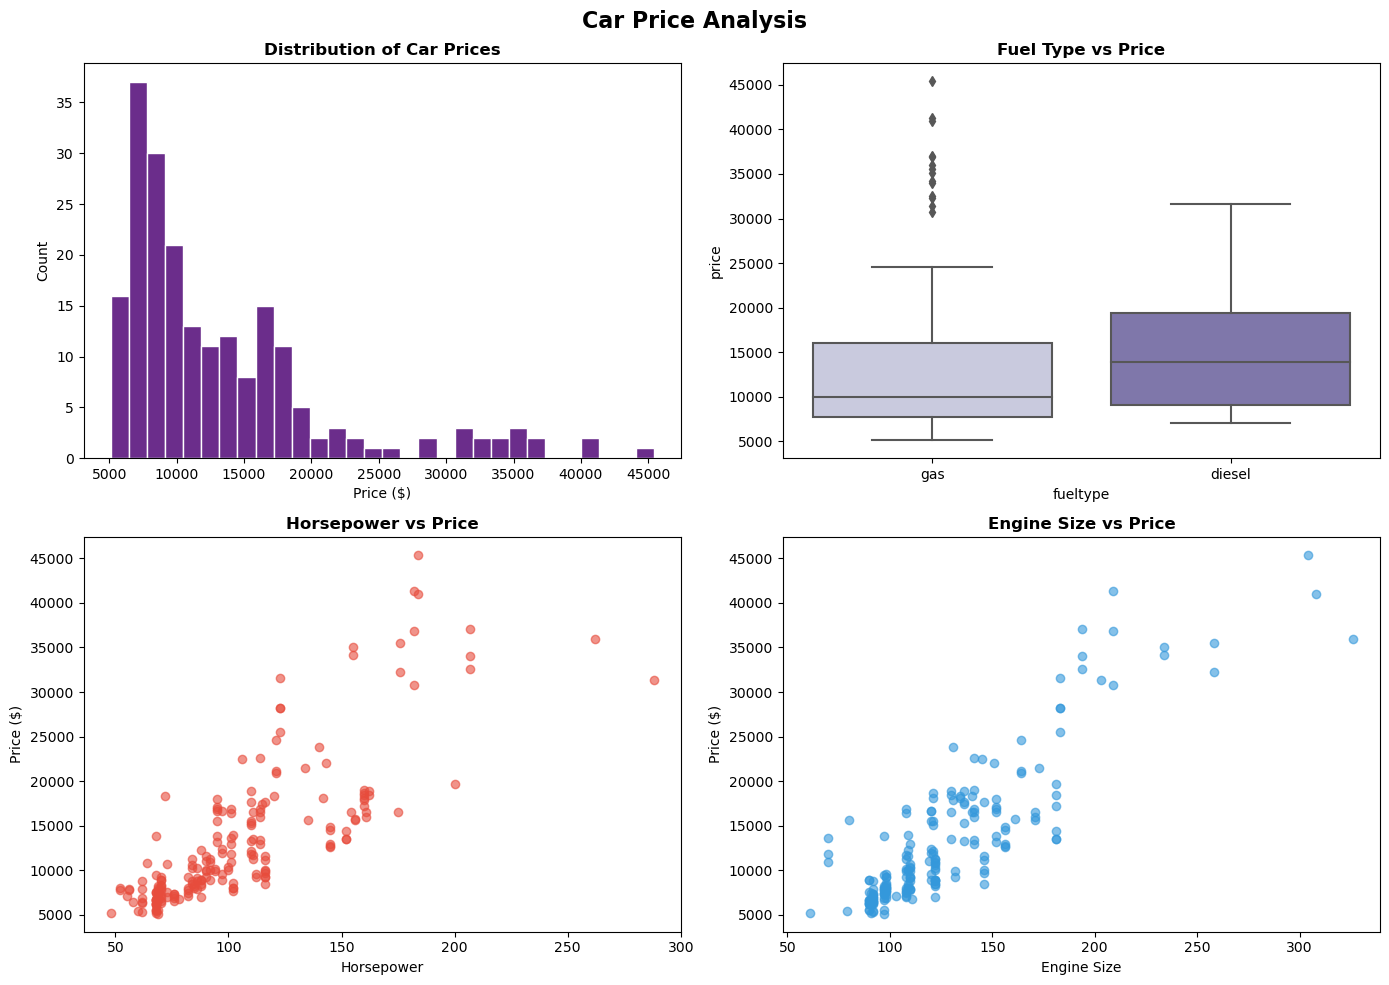

Charts saved!


In [3]:
# VISUALISE 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Car Price Analysis",
             fontsize=16, fontweight="bold")

# Chart 1 — Distribution of prices
axes[0,0].hist(df["price"], bins=30,
               color="#6B2D8B", edgecolor="white")
axes[0,0].set_title("Distribution of Car Prices",
                     fontweight="bold")
axes[0,0].set_xlabel("Price ($)")
axes[0,0].set_ylabel("Count")

# Chart 2 — Fuel type vs price
sns.boxplot(data=df, x="fueltype", y="price",
            palette="Purples", ax=axes[0,1])
axes[0,1].set_title("Fuel Type vs Price",
                     fontweight="bold")

# Chart 3 — Horsepower vs price
axes[1,0].scatter(df["horsepower"], df["price"],
                  color="#E74C3C", alpha=0.6)
axes[1,0].set_title("Horsepower vs Price",
                     fontweight="bold")
axes[1,0].set_xlabel("Horsepower")
axes[1,0].set_ylabel("Price ($)")

# Chart 4 — Engine size vs price
axes[1,1].scatter(df["enginesize"], df["price"],
                  color="#3498DB", alpha=0.6)
axes[1,1].set_title("Engine Size vs Price",
                     fontweight="bold")
axes[1,1].set_xlabel("Engine Size")
axes[1,1].set_ylabel("Price ($)")

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=120)
plt.show()

print("Charts saved!")

In [4]:
# PREPARE DATA 
print("Preparing data for ML...")

df_ml = df.copy()

# EXTRACT CAR BRAND FROM CarName 
# CarName has brand + model like "alfa-romero giulia"
# We extract just the brand!

df_ml["brand"] = df_ml["CarName"].apply(
    lambda x: x.split(" ")[0].lower()
)

print(f"\n Car brands found:")
print(df_ml["brand"].value_counts())

# DROP UNNECESSARY COLUMNS 
df_ml = df_ml.drop([
    "car_ID",     # just an ID number
    "CarName",    # replaced by brand
], axis=1)

# ENCODE TEXT COLUMNS 
# Convert all text columns to numbers

le = LabelEncoder()

text_columns = [
    "fueltype", "aspiration", "doornumber",
    "carbody", "drivewheel", "enginelocation",
    "enginetype", "cylindernumber", "fuelsystem",
    "brand"
]

for col in text_columns:
    df_ml[col] = le.fit_transform(df_ml[col])

print("\nText columns encoded!")
print(df_ml.head())

# SPLIT FEATURES AND TARGET 
X = df_ml.drop("price", axis=1)
y = df_ml["price"]

print(f"\n Features : {X.shape}")
print(f" Target   : {y.shape}")

# TRAIN TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n Training set : {X_train.shape[0]} cars")
print(f" Testing set  : {X_test.shape[0]} cars")
print("\n Data ready!")

Preparing data for ML...

 Car brands found:
brand
toyota         31
nissan         18
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
dodge           9
volkswagen      9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
jaguar          3
chevrolet       3
vw              2
maxda           2
renault         2
toyouta         1
vokswagen       1
mercury         1
porcshce        1
Name: count, dtype: int64

Text columns encoded!
   symboling  fueltype  aspiration  doornumber  carbody  drivewheel  \
0          3         1           0           1        0           2   
1          3         1           0           1        0           2   
2          1         1           0           1        2           2   
3          2         1           0           0        3           1   
4          2         1           0           0        3    

In [6]:
# TRAIN MODELS
print("="*50)
print("TRAINING ML MODELS")
print("="*50)

# MODEL 1: LINEAR REGRESSION
print("\n Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)

print(f"   MAE : ${lr_mae:,.2f}")
print(f"   R²  : {lr_r2:.4f}")

# MODEL 2: RANDOM FOREST
print("\nTraining Random Forest...")
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print(f"   MAE : ${rf_mae:,.2f}")
print(f"   R²  : {rf_r2:.4f}")

# COMPARE
print("\n" + "="*50)
print(" MODEL COMPARISON")
print("="*50)
print(f"\n{'Model':<20} {'MAE':>10} {'R²':>10}")
print("-"*42)
print(f"{'Linear Regression':<20} ${lr_mae:>9,.2f} {lr_r2:>10.4f}")
print(f"{'Random Forest':<20} ${rf_mae:>9,.2f} {rf_r2:>10.4f}")

best = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
print(f"\n Best Model: {best}")

TRAINING ML MODELS

 Training Linear Regression...
   MAE : $2,127.47
   R²  : 0.8411

Training Random Forest...
   MAE : $1,323.27
   R²  : 0.9556

 MODEL COMPARISON

Model                       MAE         R²
------------------------------------------
Linear Regression    $ 2,127.47     0.8411
Random Forest        $ 1,323.27     0.9556

 Best Model: Random Forest


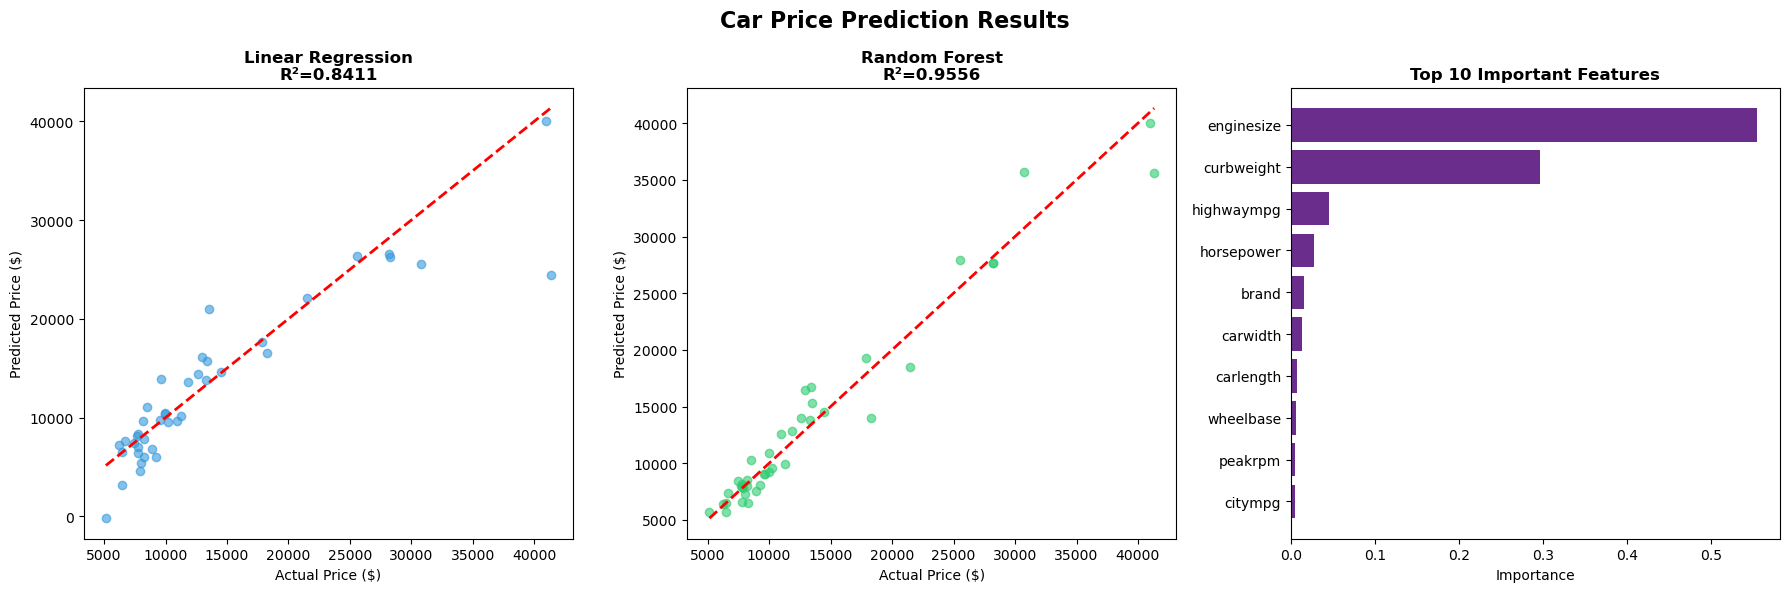

 Results saved!


In [7]:
# VISUALISE RESULTS 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Car Price Prediction Results",
             fontsize=16, fontweight="bold")

# Chart 1 — Linear Regression predictions
axes[0].scatter(y_test, lr_pred,
                alpha=0.6, color="#3498DB")
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--", linewidth=2)
axes[0].set_title(f"Linear Regression\nR²={lr_r2:.4f}",
                  fontweight="bold")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")

# Chart 2 — Random Forest predictions
axes[1].scatter(y_test, rf_pred,
                alpha=0.6, color="#2ECC71")
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--", linewidth=2)
axes[1].set_title(f"Random Forest\nR²={rf_r2:.4f}",
                  fontweight="bold")
axes[1].set_xlabel("Actual Price ($)")
axes[1].set_ylabel("Predicted Price ($)")

# Chart 3 — Feature importance
feature_imp = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True).tail(10)

axes[2].barh(feature_imp["Feature"],
             feature_imp["Importance"],
             color="#6B2D8B")
axes[2].set_title("Top 10 Important Features",
                  fontweight="bold")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("model_results.png", dpi=120)
plt.show()

print(" Results saved!")

In [8]:
# PREDICT A REAL CAR 
print("="*50)
print(" PREDICT A REAL CAR PRICE!")
print("="*50)

# BMW 3 Series style car
new_car = pd.DataFrame({
    "symboling"       : [0],
    "fueltype"        : [1],    # gas
    "aspiration"      : [1],    # std
    "doornumber"      : [1],    # four
    "carbody"         : [3],    # sedan
    "drivewheel"      : [2],    # rwd
    "enginelocation"  : [0],    # front
    "wheelbase"       : [103.0],
    "carlength"       : [178.0],
    "carwidth"        : [67.0],
    "carheight"       : [54.0],
    "curbweight"      : [2800],
    "enginetype"      : [0],    # dohc
    "cylindernumber"  : [2],    # six
    "enginesize"      : [164],
    "fuelsystem"      : [4],    # mpfi
    "boreratio"       : [3.31],
    "stroke"          : [3.19],
    "compressionratio": [9.0],
    "horsepower"      : [121],
    "peakrpm"         : [5000],
    "citympg"         : [21],
    "highwaympg"      : [28],
    "brand"           : [2],    # bmw
})

predicted_price = rf.predict(new_car)[0]

print(f"""
Car Profile:
   Brand      : BMW
   Body       : Sedan
   Engine     : 164cc, 6 cylinders
   Horsepower : 121 hp
   Drive      : RWD

Predicted Price: ${predicted_price:,.2f}
""")

# ── FINAL SUMMARY ────────────────────────────────────
print("="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"""
Dataset    : 205 cars, 26 features
Target     : Car price ($)

Results:
→ Linear Regression  R²: {lr_r2:.4f}
→ Random Forest      R²: {rf_r2:.4f}  ← Best!

Key Findings:
→ Engine size is most important feature
→ Horsepower strongly affects price
→ Car brand significantly impacts price
→ Random Forest beats Linear Regression

Car Price Prediction Project Complete!
""")

 PREDICT A REAL CAR PRICE!

Car Profile:
   Brand      : BMW
   Body       : Sedan
   Engine     : 164cc, 6 cylinders
   Horsepower : 121 hp
   Drive      : RWD

Predicted Price: $18,686.78

PROJECT SUMMARY

Dataset    : 205 cars, 26 features
Target     : Car price ($)

Results:
→ Linear Regression  R²: 0.8411
→ Random Forest      R²: 0.9556  ← Best!

Key Findings:
→ Engine size is most important feature
→ Horsepower strongly affects price
→ Car brand significantly impacts price
→ Random Forest beats Linear Regression

Car Price Prediction Project Complete!

